# penguins

In [1]:
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
import os
import random
import numpy as np

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
#    torch.manual_seed(seed)
#    torch.cuda.manual_seed(seed)
#    torch.backends.cudnn.deterministic = True
#    torch.backends.cudnn.benchmark = False

seed_everything(42)

In [3]:
df = sns.load_dataset('penguins')

In [4]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [5]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [6]:
df.tail()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female
343,Gentoo,Biscoe,49.9,16.1,213.0,5400.0,Male


In [7]:
print(df.shape)

(344, 7)


In [8]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [10]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [13]:
print(df.species.unique())
print(df.island.unique())
print(df.sex.unique())

['Adelie' 'Chinstrap' 'Gentoo']
['Torgersen' 'Biscoe' 'Dream']
['Male' 'Female']


In [14]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

dfi = df.copy()

dfi['species'] = label_encoder.fit_transform(dfi['species'])
print(label_encoder.classes_)
dfi['island'] = label_encoder.fit_transform(dfi['island'])
print(label_encoder.classes_)
dfi['sex'] = label_encoder.fit_transform(dfi['sex'])
print(label_encoder.classes_)

['Adelie' 'Chinstrap' 'Gentoo']
['Biscoe' 'Dream' 'Torgersen']
['Female' 'Male']


In [15]:
dfi.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,2,39.1,18.7,181.0,3750.0,1
1,0,2,39.5,17.4,186.0,3800.0,0
2,0,2,40.3,18.0,195.0,3250.0,0
4,0,2,36.7,19.3,193.0,3450.0,0
5,0,2,39.3,20.6,190.0,3650.0,1


In [16]:
y_data = dfi[['species']].values
dfi.drop('species', axis=1, inplace=True)
X_data = dfi.values

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2) # train과 test를 8:2로 분할

In [18]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [19]:
import xgboost as xgb ## XGBoost 불러오기
from xgboost import plot_importance ## Feature Importance를 불러오기 위함

In [20]:
model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.08, gamma=0, subsample=0.75,
                           colsample_bytree=1, max_depth=7)

In [21]:
model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [22]:
y = model.predict(X_train)

In [23]:
print(y.shape)
print(y_train.shape)

(266,)
(266, 1)


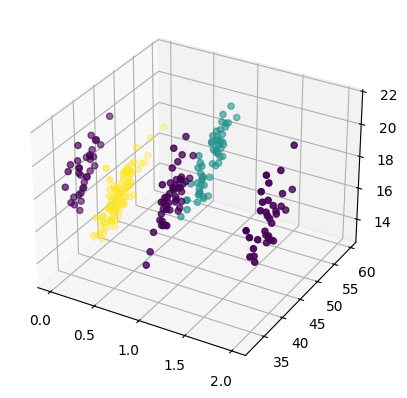

In [24]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d, Axes3D 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train[:,0], X_train[:,1], X_train[:,2], c = y_train.reshape(-1))
plt.show()

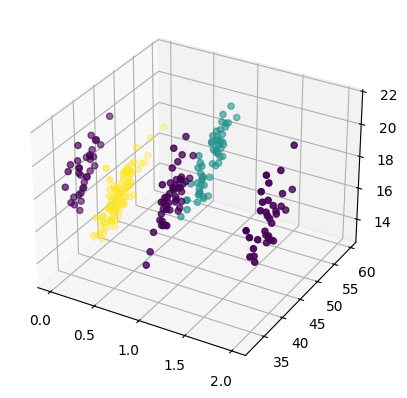

In [25]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d, Axes3D 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train[:,0], X_train[:,1], X_train[:,2], c = y)
plt.show()

In [26]:
print(model.score(X_train, y_train))

1.0


In [27]:
print(model.score(X_test, y_test))

1.0


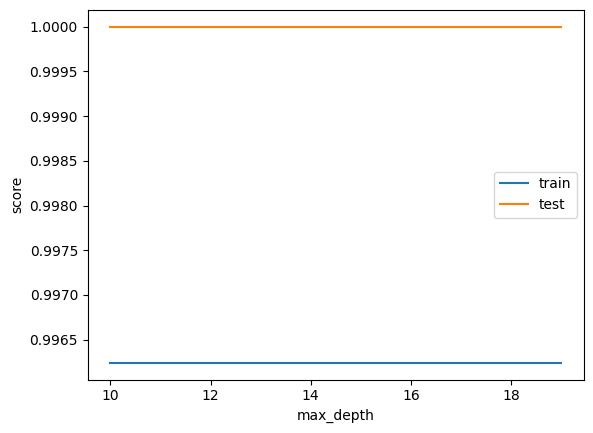

In [28]:
train_score = []
test_score = []
n_range = range(10, 20)

for n in n_range:
    model = xgb.XGBClassifier(n_estimators=n, learning_rate=0.08, gamma=0, subsample=0.75,
                           colsample_bytree=1, max_depth=10)
    model.fit(X_train, y_train)
    train_score.append(model.score(X_train, y_train))
    test_score.append(model.score(X_test, y_test))

plt.figure()
plt.plot(n_range, train_score, label='train')
plt.plot(n_range, test_score, label='test')
plt.legend()
plt.xlabel('max_depth')
plt.ylabel('score')
plt.show()

In [29]:
from sklearn import metrics

y_pred = model.predict(X_test)
print('accuarcy_score: ', metrics.accuracy_score(y_test, y_pred))
print('balanced_accuarcy_score: ', metrics.balanced_accuracy_score(y_test, y_pred))
print('classification_report: ', metrics.classification_report(y_test,y_pred))

r = metrics.classification_report(y_test,y_pred, output_dict=True)
print(r)

accuarcy_score:  1.0
balanced_accuarcy_score:  1.0
classification_report:                precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67

{'0': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 31.0}, '1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 13.0}, '2': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 23.0}, 'accuracy': 1.0, 'macro avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 67.0}, 'weighted avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 67.0}}
